<a href="https://colab.research.google.com/github/lendy0/mcu115/blob/main/CRUD_0617.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*Nus3zpMLMhI9TKZ324e4aw.jpeg)

# 關聯(關係)式資料庫

資料表( Table )是資料庫( Database )中存放資料( Data )和資料與資料之間關係( Relationship )的集合。

一個資料庫裡面通常都包含多個表，如學生的表、班級的表、課程的表...等等，表裡面存放資料，如學生的表裡面存放學生的資料、班級的表裡面存放班級的資料、課程的表裡面存放課程的資料...等等。為了能找到表中的資料，表裡面的每筆紀錄往往都會分配唯一的 ID，即所謂的主鍵( Primary Key)，藉此找到每筆紀錄。

外鍵( Foreign Key )是用來建立資料表之間的關係，其外鍵內含值必須要與另一個資料表的主鍵相同。即表和表之間的關聯是通過外鍵。

> **小提醒**：本課程會透過 `users` 表與 `orders` 表的實際範例，展示主鍵與外鍵如何運作。

### 先建立 `users` 與 `orders` 表

```sql
CREATE TABLE users (
    UID     INTEGER PRIMARY KEY AUTOINCREMENT,
    UNAME   TEXT,
    CONTACT TEXT
);

CREATE TABLE orders (
    OID     INTEGER PRIMARY KEY AUTOINCREMENT,
    USER_ID INTEGER,
    PRODUCT TEXT,
    PRICE   REAL,
    FOREIGN KEY (USER_ID) REFERENCES users(UID)
);
```
```mermaid
%%{init: {"er": {"layoutDirection": "LR"}} }%%
erDiagram
    users ||--o{ orders : "USER_ID references UID"
    users {
        int UID PK
        string UNAME
        string CONTACT
    }
    orders {
        int OID PK
        int USER_ID FK
        string PRODUCT
        float PRICE
    }
```



> **DDL vs DML**：
> - **DDL (Data Definition Language)** — 定義資料庫結構，如 `CREATE`、`ALTER`、`DROP`，上面兩段 `CREATE TABLE` 即為 DDL。
> - **DML (Data Manipulation Language)** — 操作資料內容，如 `INSERT`、`SELECT`、`UPDATE`、`DELETE`。

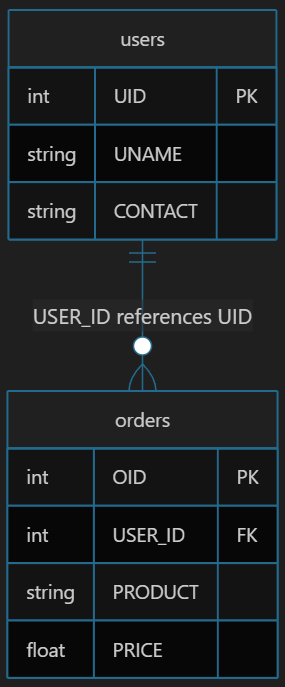

# DB-API
Python 應用程式如果要連結到資料庫，如 MySQL、SQL Server、PostgreSQL 亦或是 SQLite，因為 Python 定義了一套操作資料庫的 API，稱 DB-API，不同的資料庫只需要提供符合 DB-API 的資料庫驅動程式( Driver )，各種各樣的資料庫系統，就能有一致的操作介面，也就是說，開發者能使用 DB-API，來操作不同資料庫。

DB-API與底層資料庫互動示例：

①程式碼 ⇆ ②使用DB-API ⇆ ③資料庫驅動程式 ⇆ ④底層資料庫(如SQLite、MySQL等)

舉例來說，SQLite 是用C寫的一種體積很小的關聯式資料庫，它的資料庫就是一個檔案，所以經常被整合到應用程式中，在 iOS 和 Android 的 App 中都可以看到。Python 內置了 SQLite3 的驅動程式，所以，在 Python 中使用 SQLite 是不需要再安裝任何東西，就可以直接導入( import )使用，直接操作 SQLite 資料庫。

要操作關聯式資料庫，首先需要建立資料庫連線，一個資料庫的連線稱為一個 Connection。透過資料庫的連線，可以建立游標( Cursor )，通過 Cursor 執行 SQL 語句，然後得到執行結果。


In [ ]:
# 使用 Context Manager 建立 student 資料表並新增資料
import sqlite3

with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    # 若 student 表已存在則先刪除，方便重複執行
    cursor.execute("DROP TABLE IF EXISTS student")
    cursor.execute("CREATE TABLE student (id varchar(20) primary key, name varchar(20))")
    # 使用參數化查詢新增三筆資料
    cursor.execute("INSERT INTO student (id, name) VALUES (?, ?)", ('1', 'lendy'))
    cursor.execute("INSERT INTO student (id, name) VALUES (?, ?)", ('2', 'mary'))
    cursor.execute("INSERT INTO student (id, name) VALUES (?, ?)", ('3', 'bill'))
    conn.commit()
    print(f"新增完成，rowcount={cursor.rowcount}") # 新增完成，rowcount=1 !!!!

In [ ]:
# 查詢全部
with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute("select * from student")
    data = cursor.fetchall()
    print(data)

In [ ]:
# 查詢 id=1
with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    # cursor.execute("select * from student where id = ?", (1,))
    cursor.execute("select * from student where id = '" + '1' + "'")
    data = cursor.fetchall()
    print(data)

## 更好的寫法：參數化查詢與 Context Manager

### 為什麼要用參數化查詢？

```python
# ❌ 不好的寫法：直接拼接字串
cursor.execute("insert into student values ('1', 'lendy')")

id = '1'
name = 'lendy'
cursor.execute("insert into student values ('"+ id +"', '"+ name +"')")

# ✅ 好的寫法：使用 ? 佔位符
cursor.execute("insert into student values (?, ?)", ('1', 'lendy'))
```

使用 `?` 的好處（附範例說明）：

#### ① 安全性 — 避免 SQL Injection 攻擊

假設使用者輸入姓名為 `" ' OR '1'='1"`：

```python
# ❌ 拼接字串：SQL 語句被竄改
name = "' OR '1'='1"
cursor.execute(f"select * from users where UNAME='{name}'")
# 實際執行 → select * from users where UNAME='' OR '1'='1'
# 恆真條件，會回傳所有使用者的資料！

# ✅ 參數化查詢：? 視為純資料，不會被當成 SQL 指令
cursor.execute("select * from users where UNAME=?", (name,))
# 安全地查詢名字為 "' OR '1'='1" 的使用者（不存在則回傳空）
```

#### ② 可讀性 — SQL 語法與資料分離

```python
# ❌ 拼接字串：資料混雜在 SQL 中，難閱讀、難維護
cursor.execute("insert into student values (" + "'1'" + ", " + "'lendy'" + ")")

# ✅ 參數化查詢：SQL 結構與資料清楚分離
cursor.execute("insert into student values (?, ?)", ('1', 'lendy'))
```

#### ③ 型別處理 — 驅動程式會自動處理型別轉換

```python
# ❌ 拼接字串：需手動轉型，容易遺漏
price = 15000
cursor.execute(f"insert into orders (PRODUCT, PRICE) values ('手機', {price})")
# 若 price 是 None 會產生錯誤

# ✅ 參數化查詢：Python 型別自動對應 SQL 型別
cursor.execute("insert into orders (PRODUCT, PRICE) values (?, ?)", ('手機', 15000))
# int → SQL INTEGER, float → REAL, str → TEXT, None → NULL
```

### 使用 Context Manager（`with` 語句）

傳統寫法需要手動 `close()`，若中間發生例外會漏關：

```python
# ❌ 傳統寫法（可能漏關）
conn = sqlite3.connect('test.db')
cursor = conn.cursor()
cursor.execute(...)
conn.commit()
cursor.close()
conn.close()

# ✅ 推薦寫法：with 語句（自動關閉）
with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute(...)
    conn.commit()
# 離開 with 區塊後，連線自動關閉
```

> **注意**：Python 的 `with` 語句會自動管理資源，即使發生例外也會正確關閉連線。

### SQL 帶參數的查詢

```python
cursor.execute('select * from user where name=? and pwd=?', ('abc', 'password'))
```

### rollback() 的使用

若想取消剛才的操作，可以呼叫 `rollback()`：

```python
with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute("insert into student values (?, ?)", ('99', 'tester'))
    conn.rollback()  # 取消新增
# 這筆資料不會存入資料庫
```

---

接下來請執行以下的程式碼 Cell，觀察實際效果。

In [ ]:
import sqlite3

with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM student")
    rows = cursor.fetchall()
    print(rows)

In [ ]:
# rollback 範例：新增後取消
import sqlite3

with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute("INSERT INTO student (id, name) VALUES (?, ?)", ('99', 'tester'))
    conn.rollback()
    print("已執行 rollback，資料未存入")

# 驗證：查詢 id=99 的資料
with sqlite3.connect('test.db') as conn:
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM student WHERE id=?", ('99',))
    result = cursor.fetchall()
    print(f"查詢 id=99 的結果：{result}")

## Python sqlite3 API

|      | API |
| :--- | :----------------------------------------------------------- |
| 1    | **sqlite3.connect(database [,timeout ,other optional arguments])** 該 API 打開一個到 SQLite 資料庫檔 database 的連結。您可以使用 ":memory:" 來在 RAM 中打開一個到 database 的資料庫連接，而不是在硬碟上打開。如果資料庫成功打開，則返回一個連線物件。當一個資料庫被多個連接訪問，且其中一個修改了資料庫，此時 SQLite 資料庫被鎖定，直到事務提交。timeout 參數表示連接等待鎖定的持續時間，直到發生異常斷開連接。timeout 參數默認是 5.0（5 秒）。如果給定的資料庫名稱 filename 不存在，則該調用將創建一個資料庫。如果您不想在目前的目錄中創建資料庫，那麼您可以指定帶有路徑的檔案名，這樣您就能在任意地方創建資料庫。 |
| 2    | **connection.cursor([cursorClass])** 該常式創建一個 **cursor**，將在 Python 資料庫程式設計中用到。該方法接受一個單一的可選的參數 cursorClass。如果提供了該參數，則它必須是一個擴展自 sqlite3.Cursor 的自訂的 cursor 類。 |
| 3    | **cursor.execute(sql [, optional parameters])** 該常式執行一個 SQL 語句。該 SQL 語句可以被參數化（即使用預留位置代替 SQL 文本）。sqlite3 模組支援兩種類型的預留位置：問號和命名預留位置（命名樣式）。例如：cursor.execute("insert into people values (?, ?)", (who, age)) |
| 4    | **connection.commit()** 該方法提交當前的事務。如果您未調用該方法，那麼自您上一次調用 commit() 以來所做的任何動作對其他資料庫連接來說是不可見的。 |
| 5    | **connection.rollback()** 該方法回滾自上一次調用 commit() 以來對資料庫所做的更改。 |
| 6    | **connection.close()** 該方法關閉資料庫連接。請注意，這不會自動調用 commit()。如果您之前未調用 commit() 方法，就直接關閉資料庫連接，您所做的所有更改將全部丟失！ |
| 7    | **cursor.fetchone()** 該方法獲取查詢結果集中的下一行，返回一個單一的序列，當沒有更多可用的資料時，則返回 None。 |
| 8    | **cursor.fetchmany([size=cursor.arraysize])** 該方法獲取查詢結果集中的下一行組，返回一個列表。當沒有更多的可用的行時，則返回一個空的列表。該方法嘗試獲取由 size 參數指定的盡可能多的行。 |
| 9    | **cursor.fetchall()** 該常式獲取查詢結果集中所有（剩餘）的行，返回一個列表。當沒有可用的行時，則返回一個空的列表。 |
| 10   | **connection.total_changes()** 該常式返回自資料庫連接打開以來被修改、插入或刪除的資料庫總行數。 |


# 範例
```python
import sqlite3 as sql

#connect to SQLite
con = sql.connect('db_web.db')

#Create a Connection
cur = con.cursor()

#Drop users table if already exsist.
cur.execute("DROP TABLE IF EXISTS users")

#Create users table  in db_web database
sql ='''CREATE TABLE "users" (
	"UID"	INTEGER PRIMARY KEY AUTOINCREMENT,
	"UNAME"	TEXT,
	"CONTACT"	TEXT
)'''
cur.execute(sql)

#commit changes
con.commit()

#close the connection
con.close()
```

> **補充**：`AUTOINCREMENT` 會讓 `UID` 在新增資料時自動遞增，不需要手動給值。若不寫 `AUTOINCREMENT`，SQLite 也會自動遞增，但加上可明確表達意圖。

In [13]:
import sqlite3 as sql

# connect to SQLite
con = sql.connect('db_web.db')

# Create a Connection
cur = con.cursor()

# Drop users table if already exsist.
cur.execute("DROP TABLE IF EXISTS users")

# Create users table  in db_web database
sql ='''CREATE TABLE "users" (
    "UID"   INTEGER PRIMARY KEY AUTOINCREMENT,
    "UNAME" TEXT,
    "CONTACT"   TEXT
)'''
cur.execute(sql)

# commit changes
con.commit()

# close the connection
con.close()

In [ ]:
import sqlite3 as sql

# Connect to the database
con = sql.connect('db_web.db')
cur = con.cursor()

# Insert sample data into the users table
cur.execute("INSERT INTO users (UNAME, CONTACT) VALUES (?, ?)", ('Alice', 'alice@example.com'))
cur.execute("INSERT INTO users (UNAME, CONTACT) VALUES (?, ?)", ('Bob', 'bob@example.com'))
cur.execute("INSERT INTO users (UNAME, CONTACT) VALUES (?, ?)", ('Charlie', 'charlie@example.com'))

# Commit the changes
con.commit()

print(f"新增完成，影響 {cur.rowcount} 筆資料 (最後一筆)")

# Verify the inserted data
cur.execute("SELECT * FROM users")
print("目前資料庫內容：", cur.fetchall())

# Close the connection
cur.close()
con.close()

# 範例步驟

## import

## CRUD(新增:Create , 讀取:Read, 更新: Update, 刪除:Delete)

### Read
```Python
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("select * from users")
data = cur.fetchall()
data
```

#### row_factory 是什麼？

預設查詢結果以 **tuple** 回傳（如 `(1, 'lendy', ...)`），需用索引取值（`row[0]`、`row[1]`）。若設定 `row_factory=sql.Row`，則可用**欄位名稱**取值（如 `row['UNAME']`），程式碼更易讀。下方程式碼將示範兩種方式。

In [15]:
import sqlite3 as sql

In [ ]:
# 預設查詢結果為 tuple
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("select * from users")
data = cur.fetchall()
print("預設（tuple）：")
for row in data:
    print(row)
    print(f"UID={row[0]}, UNAME={row[1]}, CONTACT={row[2]}")
    # print(f"UID={row['UID']}, UNAME={row['UNAME']}, CONTACT={row['CONTACT']}")

cur.close()
con.close()

# 使用 row_factory 可以用欄位名稱取值
con2 = sql.connect("db_web.db")
con2.row_factory = sql.Row
cur2 = con2.cursor()
cur2.execute("select * from users")
rows = cur2.fetchall()
print("\n使用 row_factory（可用欄位名稱）：")
for row in rows:
    print(f"UID={row['UID']}, UNAME={row['UNAME']}, CONTACT={row['CONTACT']}")
cur2.close()
con2.close()

### Create
```Python
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("insert into users(UNAME,CONTACT) values (?,?)",('lendy','lendy.lin@gmail.com'))
con.commit()
```

In [ ]:
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("insert into users(UNAME,CONTACT) values (?,?)",('mary','mary.lu@gmail.com'))
con.commit()
print(f"新增完成，影響 {cur.rowcount} 筆")

# 驗證：查詢所有資料確認新增成功
cur.execute("select * from users")
print("目前資料庫內容：", cur.fetchall())
cur.close()
con.close()

### Update
```python
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("update users set UNAME=?,CONTACT=? where UID=?",('bill','bill.chen@gmail.com','1'))
con.commit()
```

In [ ]:
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("update users set UNAME=?,CONTACT=? where UID=?",('bill','bill.chen@gmail.com','2'))
con.commit()
print(f"更新完成，影響 {cur.rowcount} 筆")

# 驗證：查詢被更新的資料
cur.execute("select * from users where UID=?", ('2',))
print("更新後該筆資料：", cur.fetchall())
cur.close()
con.close()

### Delete
```python
con=sql.connect("db_web.db")
cur=con.cursor()
cur.execute("delete from users where UID=?",('1',))
con.commit()
```

In [ ]:
con = sql.connect("db_web.db")
cur = con.cursor()
cur.execute("delete from users where UID=?",('2',))
con.commit()
print(f"刪除完成，影響 {cur.rowcount} 筆")

# 驗證：查詢剩餘資料
cur.execute("select * from users")
print("刪除後剩餘資料：", cur.fetchall())
cur.close()
con.close()

# 關聯示範：users 與 orders

前面提到**外鍵 (Foreign Key)** 用來建立資料表之間的關係。現在我們新增一個 `orders` 表，記錄每個使用者的訂單：

```mermaid
%%{init: {"er": {"layoutDirection": "LR"}} }%%
erDiagram
    users ||--o{ orders : "USER_ID references UID"
    users {
        int UID PK
        string UNAME
        string CONTACT
    }
    orders {
        int OID PK
        int USER_ID FK
        string PRODUCT
        float PRICE
    }
```

- `users` 表：`UID`（主鍵 PK）唯一識別每位使用者
- `orders` 表：`OID`（主鍵 PK）唯一識別每筆訂單，`USER_ID`（外鍵 FK）指向 `users.UID`
- **圖解**：`orders.USER_ID` 的值必須來自 `users.UID`，`||--o{` 表示一對多關係

透過 `USER_ID` 這個外鍵，我們可以將訂單關聯到特定使用者，用 `JOIN` 查詢一次取得使用者名稱與其訂單明細。

In [ ]:
import sqlite3 as sql

con = sql.connect("db_web.db")
cur = con.cursor()

# 建立 orders 表，USER_ID 是外鍵，參考 users 表的 UID
cur.execute("""
    CREATE TABLE IF NOT EXISTS orders (
        OID INTEGER PRIMARY KEY AUTOINCREMENT,
        USER_ID INTEGER,
        PRODUCT TEXT,
        PRICE REAL,
        FOREIGN KEY (USER_ID) REFERENCES users(UID)
    )
""")

# 新增一些訂單資料（假設 UID=1 與 UID=2 的使用者存在）
cur.execute("INSERT INTO orders (USER_ID, PRODUCT, PRICE) VALUES (?, ?, ?)", (1, '手機', 15000))
cur.execute("INSERT INTO orders (USER_ID, PRODUCT, PRICE) VALUES (?, ?, ?)", (1, '耳機', 2000))
cur.execute("INSERT INTO orders (USER_ID, PRODUCT, PRICE) VALUES (?, ?, ?)", (2, '鍵盤', 1200))

con.commit()
print("orders 表建立完成，已新增 3 筆訂單")
cur.close()
con.close()

In [ ]:
import sqlite3 as sql

con = sql.connect("db_web.db")
con.row_factory = sql.Row
cur = con.cursor()

# JOIN 查詢：結合 users 與 orders 表，顯示使用者名稱與其訂單
cur.execute("""
    SELECT users.UNAME, orders.PRODUCT, orders.PRICE
    FROM users
    INNER JOIN orders ON users.UID = orders.USER_ID
""")
rows = cur.fetchall()
print("=== 訂單列表（JOIN 查詢）===")
for row in rows:
    print(f"{row['UNAME']} 購買了 {row['PRODUCT']}，價格 {row['PRICE']}")

cur.close()
con.close()

# 練習題

我是一個開發人員，先幫我建立一個學生類別，該物件包含學生的學號、學生的姓名、學生的成績、學生的性別，用SQLite來管理全班學生，幫我撰寫新增、修改、刪除和查詢全部學生的學號、學生的姓名、學生的成績、學生的性別，最後寫一個新增、修改、刪除、查詢全部學生和離開的使用者介面。

請輸入你的學號、姓名、成績為學號後兩碼、性別。

### 範例使用：

請運行上方代碼單元以定義所有函數。接著可以運行以下單元來測試這些功能。